<a href="https://colab.research.google.com/github/M-TOO/AI_Assignment/blob/main/Datapreprocessing_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Preprocessing Complete. Training shape: (1055, 8), Test shape: (264, 8)


/tmp/ipykernel_8325/2986810523.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="class", palette="Set2", ax=axes[0, 0])
/tmp/ipykernel_8325/2986810523.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="class", y="troponin", palette="Set2", ax=axes[1, 0])


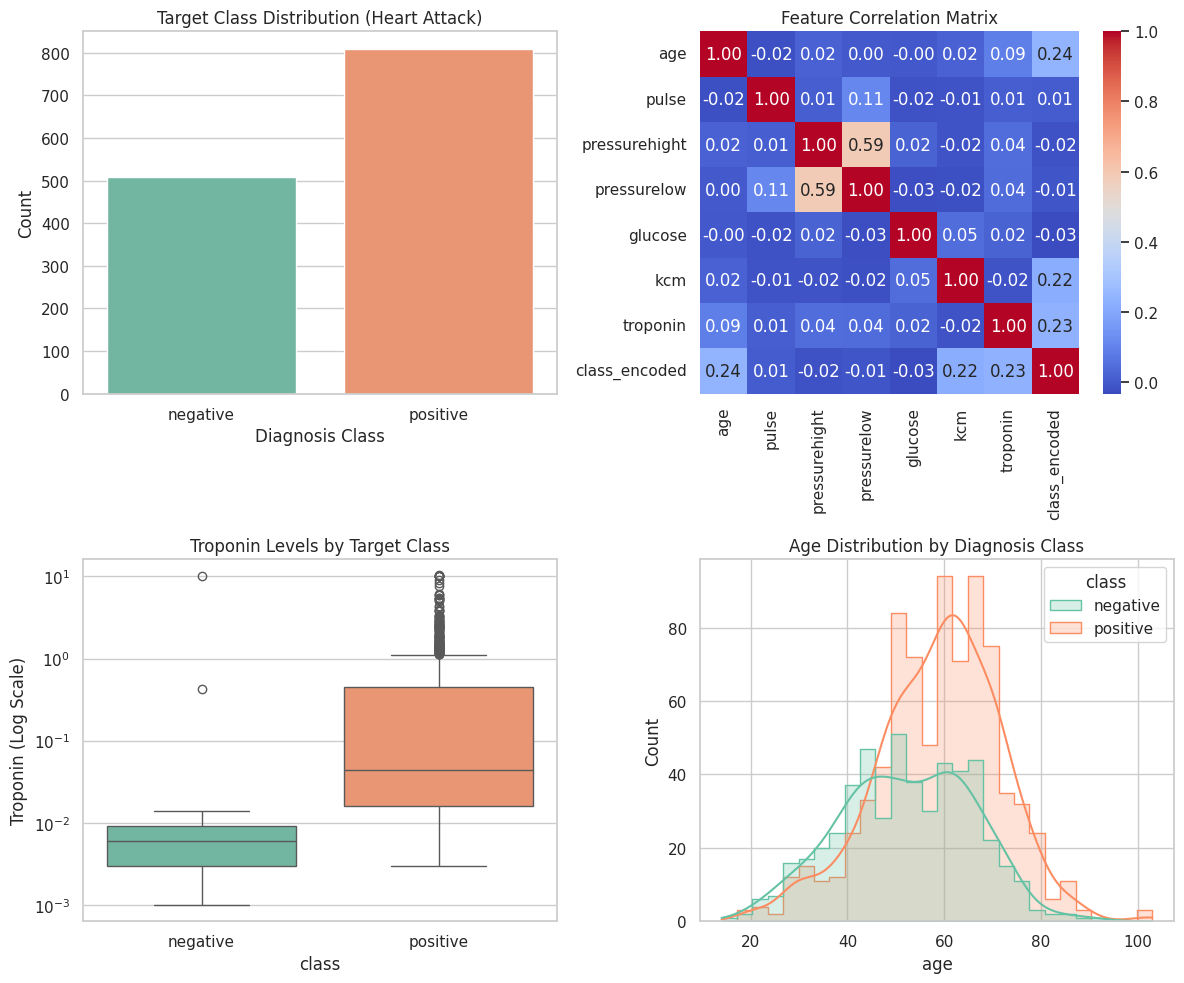

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Load the csv
df= pd.read_csv("/content/Heart Attack.csv")

#Rename the column
df.columns = df.columns.str.strip()
if "impluse" in df.columns:
    df.rename(columns={"impluse": "pulse"}, inplace=True)

#Remove the duplicates
df.drop_duplicates(inplace=True)

# Handle missing values if any exist
num_cols = [
    "age",
    "pulse",
    "pressurehight",
    "pressurelow",
    "glucose",
    "kcm",
    "troponin",
]
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

#Choose the target column
df["class_encoded"] =df["class"].map({"negative": 0, "positive": 1})

#Separate the target and the features
#Feature-Independent Variable;the clues,evidence and attributes used to make the prediction
#Target-Dependent Variable;the correct answer

X= df.drop(columns=["class","class_encoded"])
y=df["class_encoded"]

# 1. Split the raw, unscaled features first
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


scaler = StandardScaler()

# Fit AND transform training data (learns mean/std from train ONLY)
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data ONLY (uses train mean/std, does NOT peek at test stats)
X_test_scaled = scaler.transform(X_test)


print(f"Preprocessing Complete. Training shape: {X_train.shape}, Test shape: {X_test.shape}")


# --- 2. DATA VISUALIZATION ---

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Visual 1: Target Class Balance
sns.countplot(data=df, x="class", palette="Set2", ax=axes[0, 0])
axes[0, 0].set_title("Target Class Distribution (Heart Attack)")
axes[0, 0].set_xlabel("Diagnosis Class")
axes[0, 0].set_ylabel("Count")

# Visual 2: Correlation Heatmap
corr = df[num_cols + ["class_encoded"]].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", ax=axes[0, 1])
axes[0, 1].set_title("Feature Correlation Matrix")

# Visual 3: Troponin Distribution across Classes (Log Scale)
sns.boxplot(data=df, x="class", y="troponin", palette="Set2", ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("Troponin Levels by Target Class")
axes[1, 0].set_ylabel("Troponin (Log Scale)")

# Visual 4: Age Distribution by Heart Attack Class
sns.histplot(
    data=df,
    x="age",
    hue="class",
    kde=True,
    element="step",
    palette="Set2",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Age Distribution by Diagnosis Class")

plt.tight_layout()
plt.show()

SVM PERFORMANCE METRICS
   Metric    Score
 Accuracy 0.746212
Precision 0.787879
   Recall 0.802469
  F-score 0.795107
  ROC-AUC 0.827584

Detailed Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.66      0.67       102
           1       0.79      0.80      0.80       162

    accuracy                           0.75       264
   macro avg       0.73      0.73      0.73       264
weighted avg       0.74      0.75      0.75       264



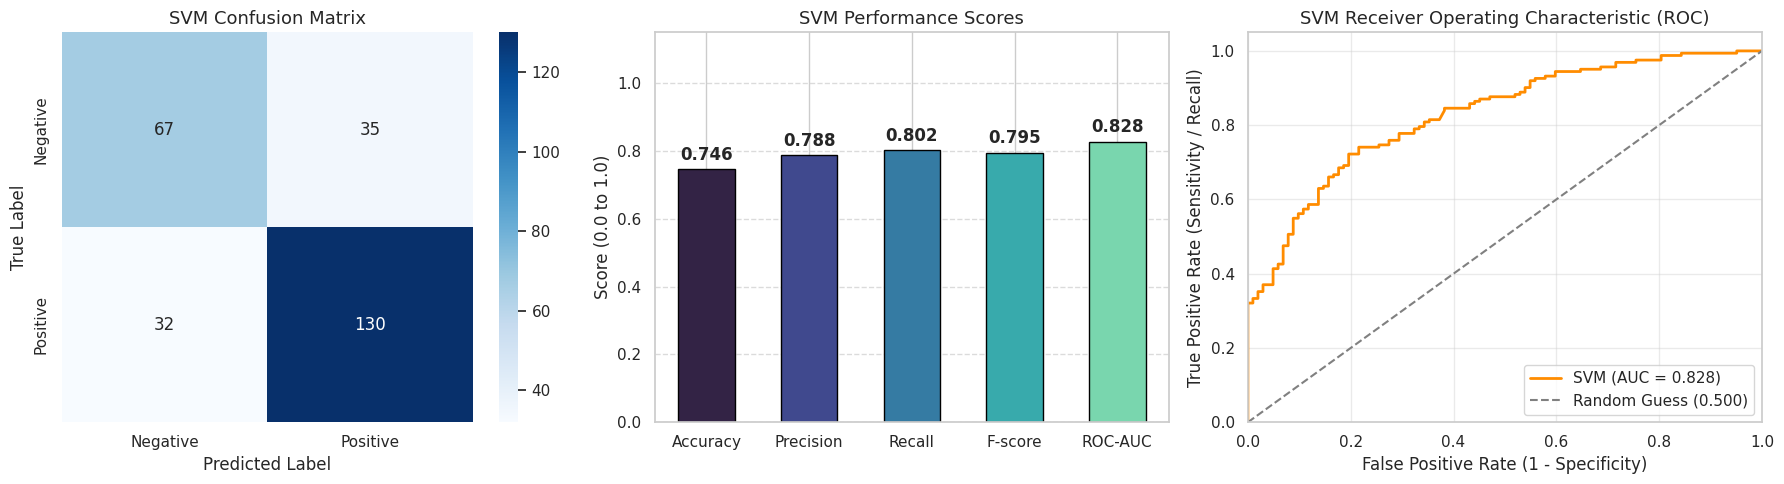

In [ ]:
#The SVM Algorithm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score,precision_score,recall_score,roc_auc_score,roc_curve,)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC


df = pd.read_csv("/content/Heart Attack.csv")


if "impluse" in df.columns:
    df.rename(columns={"impluse": "pulse"}, inplace=True)

df.drop_duplicates(inplace=True)
df["target"] = df["class"].map({"negative": 0, "positive": 1})

X = df.drop(columns=["class", "target"])
y = df["target"]

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. SVM MODEL TRAINING ---
svm_model = SVC(kernel="rbf", C=1.0, probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

# --- 3. PREDICTIONS & THE 5 PERFORMANCE METRICS ---
y_pred = svm_model.predict(X_test_scaled)
y_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

# Calculate individual metrics
svm_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

# Display metrics table
metrics_df = pd.DataFrame(list(svm_metrics.items()), columns=["Metric", "Score"])
print("=" * 40)
print("SVM PERFORMANCE METRICS")
print("=" * 40)
print(metrics_df.to_string(index=False))
print("=" * 40)
print("\nDetailed Classification Report:\n", classification_report(y_test, y_pred))

# --- 4. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0],
)
axes[0].set_title("SVM Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Graph 2: The 5 Metrics Bar Chart
palette = sns.color_palette("mako", len(svm_metrics))
bars = axes[1].bar(
    metrics_df["Metric"],
    metrics_df["Score"],
    color=palette,
    edgecolor="black",
    width=0.55,
)
axes[1].set_title("SVM Performance Scores", fontsize=13)
axes[1].set_ylabel("Score (0.0 to 1.0)")
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

# Print exact value tags on top of each bar
for bar in bars:
    height = bar.get_height()
    axes[1].annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Graph 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"SVM (AUC = {svm_metrics['ROC-AUC']:.3f})"
)
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (0.500)")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("False Positive Rate (1 - Specificity)")
axes[2].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[2].set_title("SVM Receiver Operating Characteristic (ROC)", fontsize=13)
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
#Deep Learning /Neural Networks

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential

# Set seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)


df = pd.read_csv("/content/Heart Attack.csv")
df.columns = df.columns.str.strip()

if "impluse" in df.columns:
    df.rename(columns={"impluse": "pulse"}, inplace=True)

df.drop_duplicates(inplace=True)
df["target"] = df["class"].map({"negative": 0, "positive": 1})

# Separate features and target
X = df.drop(columns=["class", "target"])
y = df["target"]

# Train/Test Split (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. BUILD & TRAIN NEURAL NETWORK ---
model = Sequential(
    [
        Dense(32, activation="relu", input_shape=(X_train_scaled.shape[1],)),
        Dropout(0.2),
        Dense(16, activation="relu"),
        Dropout(0.2),
        Dense(1, activation="sigmoid"),
    ]
)

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

history = model.fit(
    X_train_scaled,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    verbose=0,
)

# --- 3. PREDICTIONS & THE 5 METRICS ---
y_proba = model.predict(X_test_scaled).ravel()
y_pred = (y_proba >= 0.5).astype(int)

dl_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

# Display metrics table
metrics_df = pd.DataFrame(list(dl_metrics.items()), columns=["Metric", "Score"])
print("=" * 45)
print("DEEP LEARNING PERFORMANCE METRICS")
print("=" * 45)
print(metrics_df.to_string(index=False))
print("=" * 45)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 4. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0],
)
axes[0].set_title("Deep Learning Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Graph 2: The 5 Metrics Bar Chart
palette = sns.color_palette("crest", len(dl_metrics))
bars = axes[1].bar(
    metrics_df["Metric"],
    metrics_df["Score"],
    color=palette,
    edgecolor="black",
    width=0.55,
)
axes[1].set_title("Deep Learning Performance Scores", fontsize=13)
axes[1].set_ylabel("Score (0.0 to 1.0)")
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    height = bar.get_height()
    axes[1].annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Graph 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(
    fpr, tpr, color="forestgreen", lw=2, label=f"Deep Learning (AUC = {dl_metrics['ROC-AUC']:.3f})"
)
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (0.500)")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("False Positive Rate (1 - Specificity)")
axes[2].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[2].set_title("Deep Learning ROC Curve", fontsize=13)
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.show()

KNN PERFORMANCE METRICS (k=5)
   Metric    Score
 Accuracy 0.666667
Precision 0.753425
   Recall 0.679012
  F-score 0.714286
  ROC-AUC 0.731572

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.65      0.60       102
           1       0.75      0.68      0.71       162

    accuracy                           0.67       264
   macro avg       0.66      0.66      0.66       264
weighted avg       0.68      0.67      0.67       264



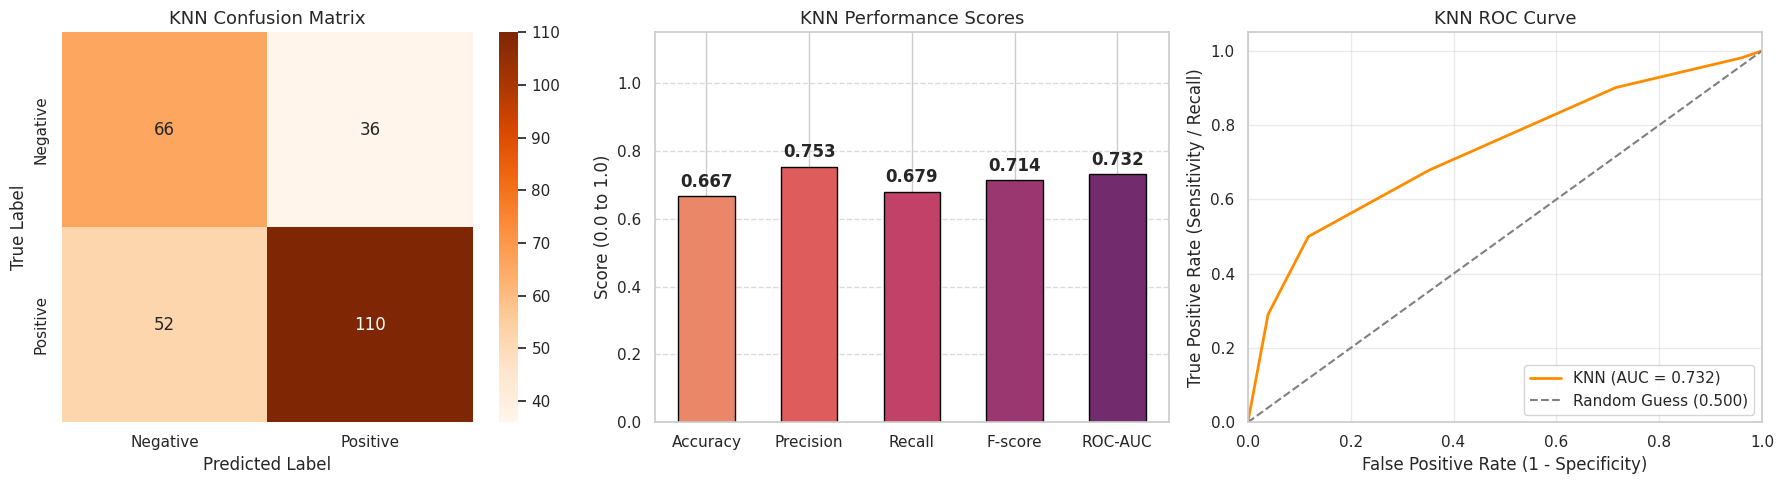

In [ ]:
#KNN
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (accuracy_score,classification_report,confusion_matrix,f1_score,precision_score,recall_score,roc_auc_score,roc_curve,)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# --- 1. DATA PREPARATION ---
df = pd.read_csv("/content/Heart Attack.csv")
df.columns = df.columns.str.strip()

if "impluse" in df.columns:
    df.rename(columns={"impluse": "pulse"}, inplace=True)

df.drop_duplicates(inplace=True)
df["target"] = df["class"].map({"negative": 0, "positive": 1})

X = df.drop(columns=["class", "target"])
y = df["target"]

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Crucial for KNN: distance metrics depend on uniform scale)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. KNN MODEL TRAINING ---
# Using k=5 with Euclidean distance (p=2)
knn_model = KNeighborsClassifier(n_neighbors=5, metric="minkowski", p=2)
knn_model.fit(X_train_scaled, y_train)

# --- 3. PREDICTIONS & THE 5 METRICS ---
y_pred = knn_model.predict(X_test_scaled)
y_proba = knn_model.predict_proba(X_test_scaled)[:, 1]

knn_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

# Display metrics table
metrics_df = pd.DataFrame(list(knn_metrics.items()), columns=["Metric", "Score"])
print("=" * 45)
print("KNN PERFORMANCE METRICS (k=5)")
print("=" * 45)
print(metrics_df.to_string(index=False))
print("=" * 45)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 4. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0],
)
axes[0].set_title("KNN Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Graph 2: The 5 Metrics Bar Chart
palette = sns.color_palette("flare", len(knn_metrics))
bars = axes[1].bar(
    metrics_df["Metric"],
    metrics_df["Score"],
    color=palette,
    edgecolor="black",
    width=0.55,
)
axes[1].set_title("KNN Performance Scores", fontsize=13)
axes[1].set_ylabel("Score (0.0 to 1.0)")
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    height = bar.get_height()
    axes[1].annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Graph 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(
    fpr, tpr, color="darkorange", lw=2, label=f"KNN (AUC = {knn_metrics['ROC-AUC']:.3f})"
)
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (0.500)")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("False Positive Rate (1 - Specificity)")
axes[2].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[2].set_title("KNN ROC Curve", fontsize=13)
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.show()

RANDOM FOREST PERFORMANCE METRICS
   Metric    Score
 Accuracy 0.984848
Precision 0.987654
   Recall 0.987654
  F-score 0.987654
  ROC-AUC 0.994069

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98       102
           1       0.99      0.99      0.99       162

    accuracy                           0.98       264
   macro avg       0.98      0.98      0.98       264
weighted avg       0.98      0.98      0.98       264



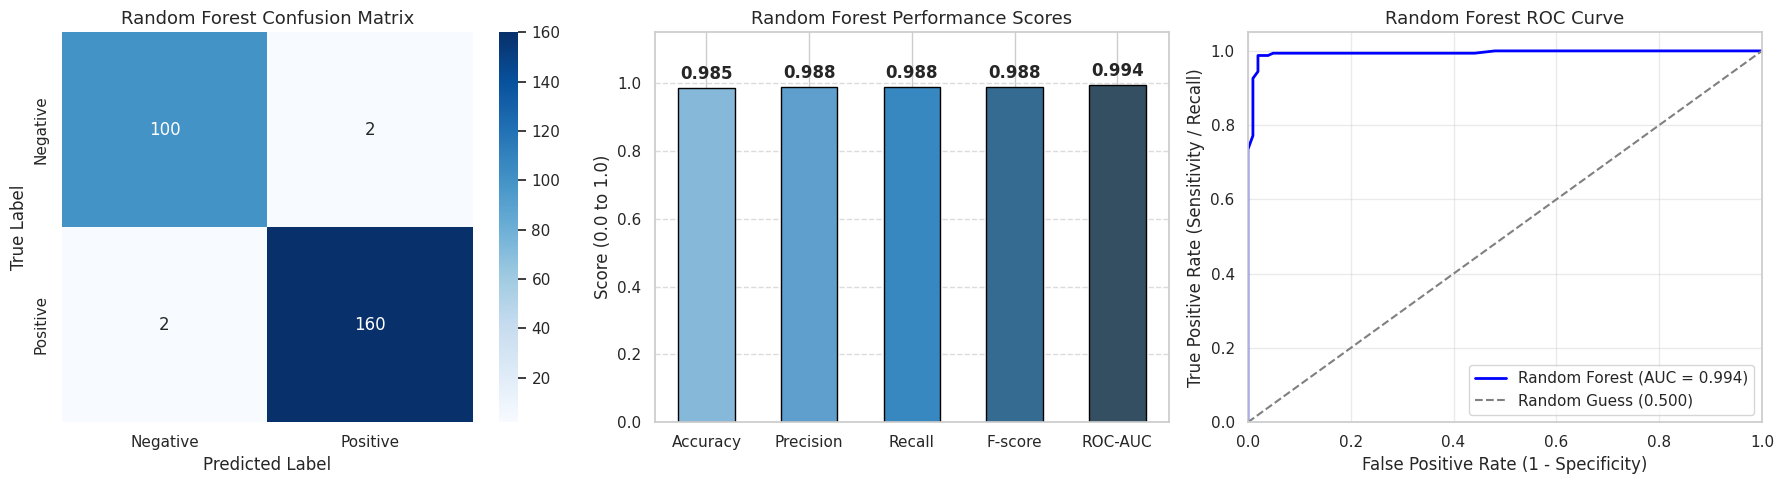

In [ ]:
#RandomForest
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


df = pd.read_csv("/content/Heart Attack.csv")
df.columns = df.columns.str.strip()

if "impluse" in df.columns:
    df.rename(columns={"impluse": "pulse"}, inplace=True)

df.drop_duplicates(inplace=True)
df["target"] = df["class"].map({"negative": 0, "positive": 1})

X = df.drop(columns=["class", "target"])
y = df["target"]

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Feature Scaling (Kept consistent across pipeline)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. RANDOM FOREST MODEL TRAINING ---
# 100 decision trees, random_state for reproducibility
rf_model = RandomForestClassifier(
    n_estimators=100, max_depth=None, random_state=42, n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train)

# --- 3. PREDICTIONS & THE 5 METRICS ---
y_pred = rf_model.predict(X_test_scaled)
y_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

rf_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

# Display metrics table
metrics_df = pd.DataFrame(list(rf_metrics.items()), columns=["Metric", "Score"])
print("=" * 45)
print("RANDOM FOREST PERFORMANCE METRICS")
print("=" * 45)
print(metrics_df.to_string(index=False))
print("=" * 45)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 4. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0],
)
axes[0].set_title("Random Forest Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Graph 2: The 5 Metrics Bar Chart
palette = sns.color_palette("Blues_d", len(rf_metrics))
bars = axes[1].bar(
    metrics_df["Metric"],
    metrics_df["Score"],
    color=palette,
    edgecolor="black",
    width=0.55,
)
axes[1].set_title("Random Forest Performance Scores", fontsize=13)
axes[1].set_ylabel("Score (0.0 to 1.0)")
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    height = bar.get_height()
    axes[1].annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Graph 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(
    fpr, tpr, color="blue", lw=2, label=f"Random Forest (AUC = {rf_metrics['ROC-AUC']:.3f})"
)
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (0.500)")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("False Positive Rate (1 - Specificity)")
axes[2].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[2].set_title("Random Forest ROC Curve", fontsize=13)
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.show()

NAIVE BAYES (GAUSSIAN) PERFORMANCE METRICS
   Metric    Score
 Accuracy 0.696970
Precision 0.988095
   Recall 0.512346
  F-score 0.674797
  ROC-AUC 0.848342

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.99      0.72       102
           1       0.99      0.51      0.67       162

    accuracy                           0.70       264
   macro avg       0.77      0.75      0.70       264
weighted avg       0.82      0.70      0.69       264



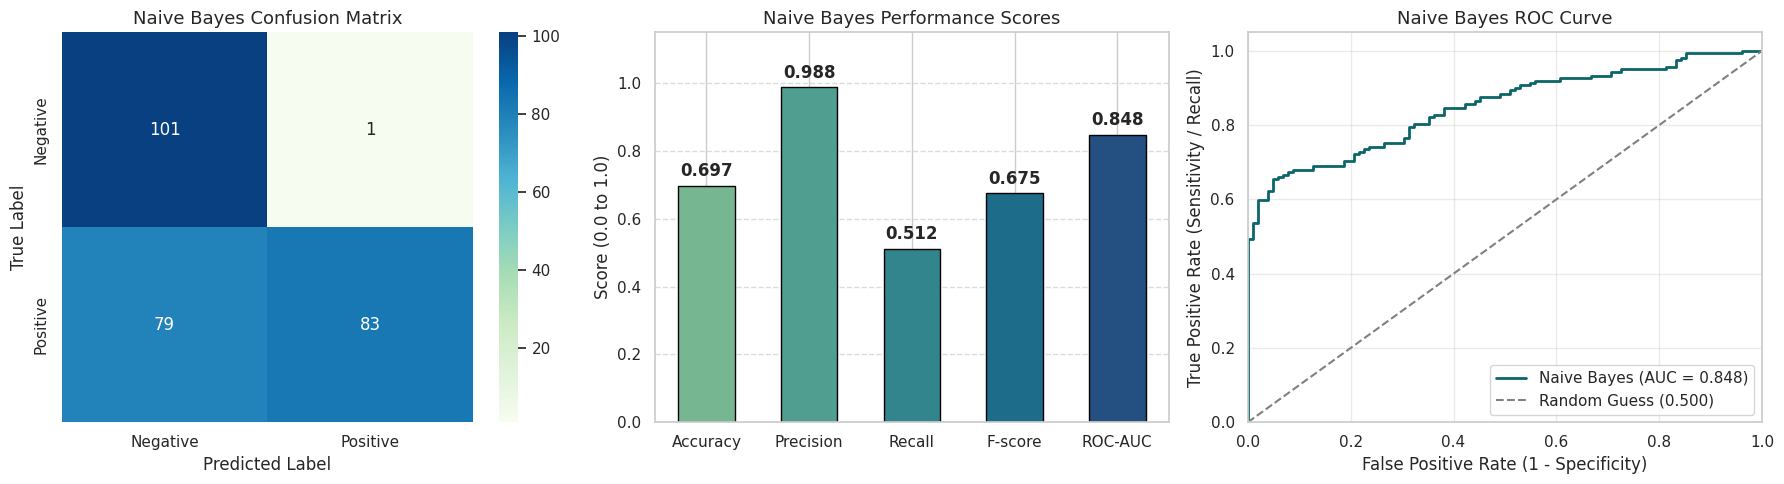

In [ ]:
# Naive-Bayes
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler

# --- 1. DATA PREPARATION ---
df = pd.read_csv("/content/Heart Attack.csv")
df.columns = df.columns.str.strip()

if "impluse" in df.columns:
    df.rename(columns={"impluse": "pulse"}, inplace=True)

df.drop_duplicates(inplace=True)
df["target"] = df["class"].map({"negative": 0, "positive": 1})

X = df.drop(columns=["class", "target"])
y = df["target"]

# 80/20 Stratified Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Standardize features (Keeps pipeline consistent across all models)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# --- 2. NAIVE BAYES TRAINING ---
# GaussianNB assumes features follow a normal (Gaussian) distribution
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

# --- 3. PREDICTIONS & THE 5 METRICS ---
y_pred = nb_model.predict(X_test_scaled)
y_proba = nb_model.predict_proba(X_test_scaled)[:, 1]

nb_metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred, zero_division=0),
    "Recall": recall_score(y_test, y_pred, zero_division=0),
    "F-score": f1_score(y_test, y_pred, zero_division=0),
    "ROC-AUC": roc_auc_score(y_test, y_proba),
}

# Display metrics table
metrics_df = pd.DataFrame(list(nb_metrics.items()), columns=["Metric", "Score"])
print("=" * 45)
print("NAIVE BAYES (GAUSSIAN) PERFORMANCE METRICS")
print("=" * 45)
print(metrics_df.to_string(index=False))
print("=" * 45)
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# --- 4. VISUALIZATIONS ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="GnBu",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"],
    ax=axes[0],
)
axes[0].set_title("Naive Bayes Confusion Matrix", fontsize=13)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

# Graph 2: The 5 Metrics Bar Chart
palette = sns.color_palette("crest", len(nb_metrics))
bars = axes[1].bar(
    metrics_df["Metric"],
    metrics_df["Score"],
    color=palette,
    edgecolor="black",
    width=0.55,
)
axes[1].set_title("Naive Bayes Performance Scores", fontsize=13)
axes[1].set_ylabel("Score (0.0 to 1.0)")
axes[1].set_ylim(0, 1.15)
axes[1].grid(axis="y", linestyle="--", alpha=0.7)

for bar in bars:
    height = bar.get_height()
    axes[1].annotate(
        f"{height:.3f}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        va="bottom",
        fontweight="bold",
    )

# Graph 3: ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[2].plot(
    fpr, tpr, color="#0b666a", lw=2, label=f"Naive Bayes (AUC = {nb_metrics['ROC-AUC']:.3f})"
)
axes[2].plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random Guess (0.500)")
axes[2].set_xlim([0.0, 1.0])
axes[2].set_ylim([0.0, 1.05])
axes[2].set_xlabel("False Positive Rate (1 - Specificity)")
axes[2].set_ylabel("True Positive Rate (Sensitivity / Recall)")
axes[2].set_title("Naive Bayes ROC Curve", fontsize=13)
axes[2].legend(loc="lower right")
axes[2].grid(alpha=0.4)

plt.tight_layout()
plt.show()